<a href="https://colab.research.google.com/github/manikdey77/manikdey77/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Return_2018_2025.csv to Return_2018_2025.csv


In [ ]:
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  # Example to read a CSV file into a DataFrame
  # df = pd.read_csv(io.BytesIO(uploaded[fn]))


User uploaded file "Return_2018_2025.csv"


In [3]:
import pandas as pd
import io

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    data = pd.read_csv(io.BytesIO(uploaded[fn]))

User uploaded file "Return_2018_2025.csv"


In [4]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1622 non-null   object 
 1   BTC     1622 non-null   float64
 2   ETH     1622 non-null   float64
 3   BNB     1622 non-null   float64
 4   SP500   1622 non-null   float64
 5   NASDAQ  1622 non-null   float64
 6   NIFTY   1622 non-null   float64
 7   EURUSD  1622 non-null   float64
 8   USDINR  1622 non-null   float64
 9   USDJPY  1622 non-null   float64
dtypes: float64(9), object(1)
memory usage: 126.8+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

In [6]:
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

In [7]:
print(data.index[:5])
print(data.index.dtype)

DatetimeIndex(['2018-04-03', '2018-04-04', '2018-04-05', '2018-04-09',
               '2018-04-10'],
              dtype='datetime64[ns]', name='Date', freq=None)
datetime64[ns]


In [ ]:
print(data.isna().sum())

BTC       0
ETH       0
BNB       0
SP500     0
NASDAQ    0
NIFTY     0
EURUSD    0
USDINR    0
USDJPY    0
dtype: int64


In [8]:
series = data[['BTC']].dropna().copy()

In [9]:
print(series.shape)
print(series.head())

(1622, 1)
                 BTC
Date                
2018-04-03  0.051223
2018-04-04 -0.084225
2018-04-05 -0.006201
2018-04-09 -0.005999
2018-04-10  0.009412


In [10]:
def create_sequences(series, lookback):
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

In [11]:
lookback = 80
initial_train_size = 500

train_series = series.iloc[:initial_train_size]

scaler = StandardScaler()
scaled_train = scaler.fit_transform(train_series.values)

X_train, y_train = create_sequences(scaled_train, lookback)
X_train = X_train.reshape((X_train.shape[0], lookback, 1))

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               dropout=0.2,
               input_shape=(lookback,1)))

model.add(LSTM(32, dropout=0.2))

model.add(Dense(16, activation='relu'))  # nonlinear projection
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='huber')

model.fit(X_train, y_train,
          epochs=50,
          batch_size=16,
          verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.3360
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3619
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3230
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.3830
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.3598
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.3380
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.3088
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3003
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3330
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.2590
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.3223
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.3539
Epoch 13/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3026
Epoch 14/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.2762
Epoch 15/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.2805
Epoch 16/50
27/

In [12]:
predictions = []
actuals = []
dates = []

scaled_full = scaler.transform(series.values)

for t in range(initial_train_size, len(series)):

    input_seq = scaled_full[t-lookback:t]
    input_seq = input_seq.reshape((1, lookback, 1))

    forecast_scaled = model.predict(input_seq, verbose=0)
    forecast = scaler.inverse_transform(forecast_scaled)[0][0]

    predictions.append(forecast)
    actuals.append(series.iloc[t].values[0])
    dates.append(series.index[t])

In [13]:
results = pd.DataFrame({
    "Raw_Return": actuals,
    "Predictable_Component": predictions
}, index=dates)

results["Innovation_Component"] = (
    results["Raw_Return"] - results["Predictable_Component"]
)

In [14]:
results.head()

,Raw_Return,Predictable_Component,Innovation_Component
2020-09-02,-0.047600,0.002960,-0.050559
2020-09-03,-0.108025,0.001578,-0.109603
2020-09-08,-0.011168,-0.004239,-0.006929
2020-09-09,0.010880,-0.007453,0.018333
2020-09-10,0.011724,-0.007934,0.019658


In [15]:
results.describe()

,Raw_Return,Predictable_Component,Innovation_Component
count,1122.000000,1122.000000,1122.000000
mean,0.001782,-0.001541,0.003323
std,0.041279,0.008160,0.041925
min,-0.291969,-0.043708,-0.287906
25%,-0.017727,-0.006772,-0.017697
50%,0.000748,-0.002387,0.001825
75%,0.020878,0.003634,0.021858
max,0.191527,0.020910,0.193489


In [16]:
(np.abs(results["Raw_Return"] -
        (results["Predictable_Component"] +
         results["Innovation_Component"])) < 1e-8).all()

np.True_

In [17]:
results.to_csv("btc_lstm_decomposition.csv")

In [18]:
from google.colab import files
files.download("btc_lstm_decomposition.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(results["Innovation_Component"], lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,21.429682,0.018289


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(
    results["Raw_Return"],
    lags=[10],
    return_df=True
)

,lb_stat,lb_pvalue
10,7.839205,0.64454


In [21]:
acorr_ljungbox(results["Innovation_Component"], lags=[5,10,15,20])

,lb_stat,lb_pvalue
5,9.949702,0.076673
10,21.429682,0.018289
15,24.374064,0.059007
20,33.191540,0.032143


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Convert lists to numpy arrays
y_true = np.array(actuals)
y_pred = np.array(predictions)

# Compute error metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")

Mean Squared Error (MSE): 0.001767
Root Mean Squared Error (RMSE): 0.042038
Mean Absolute Error (MAE): 0.028744


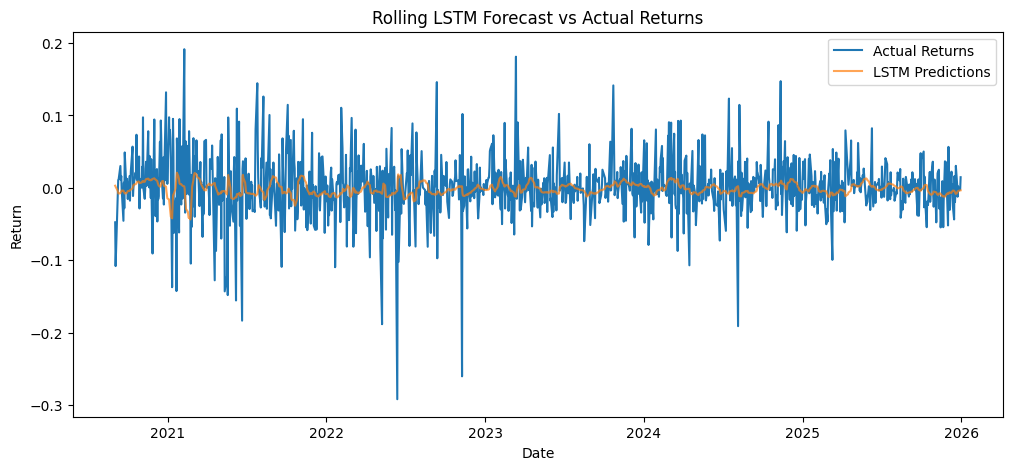

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(dates, y_true, label="Actual Returns")
plt.plot(dates, y_pred, label="LSTM Predictions", alpha=0.7)
plt.title("Rolling LSTM Forecast vs Actual Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()